# Neural Style Editing for Faces Using Diffusion Feature Control (Multi-Attribute)

- Uses the **VAE** from Stable Diffusion as a diffusion-style latent space for faces.
- Uses **CelebA** attributes (Smiling, Eyeglasses, Young, etc.).
- Trains a **separate linear probe** in latent space for each attribute.
- Interprets probe weight vectors as **attribute directions**.
- Edits faces by moving along these directions (single or multiple combined).

User can choose an attribute at runtime (e.g., "Smiling", "Eyeglasses").
Train multiple attribute directions and combine them, e.g., "more smiling + younger + add eyeglasses".

In [1]:
!pip install torch torchvision torchaudio
!pip install diffusers transformers accelerate
!pip install matplotlib tqdm gdown



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


### Imports and Config

In [1]:
import os
import random
from dataclasses import dataclass
from typing import Tuple, Dict

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms

from diffusers import AutoencoderKL
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


# %%
@dataclass
class Config:
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 42

    data_root: str = "./data"
    image_size: int = 128                 # smaller for faster CPU
    max_train_latents: int = 2000        # how many train examples to precompute
    max_val_latents: int = 200          # how many val examples to precompute

    batch_size_precompute: int = 8      # for image -> latent precompute
    num_workers: int = 0                 # avoid multiprocessing issues in notebooks

    sd_vae_model_id: str = "stabilityai/sd-vae-ft-mse"
    latent_scale: float = 0.18215

    # probe training
    batch_size_probe: int = 64
    learning_rate: float = 1e-3
    num_epochs: int = 10
    weight_decay: float = 1e-4

    edit_step_scale: float = 4.0
    num_visualization_samples: int = 8

    latents_file: str = "./celeba_sdvae_latents.pt"


cfg = Config()
print(cfg)


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(cfg.seed)

/Users/jishilin/.venvs/vsc-py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Config(device='cpu', seed=42, data_root='./data', image_size=128, max_train_latents=2000, max_val_latents=200, batch_size_precompute=8, num_workers=0, sd_vae_model_id='stabilityai/sd-vae-ft-mse', latent_scale=0.18215, batch_size_probe=64, learning_rate=0.001, num_epochs=10, weight_decay=0.0001, edit_step_scale=4.0, num_visualization_samples=8, latents_file='./celeba_sdvae_latents.pt')


## Load Stable Diffusion VAE (Diffusion Latent Space)

In [2]:
vae = AutoencoderKL.from_pretrained(cfg.sd_vae_model_id)
vae.to(cfg.device)
vae.eval()
for p in vae.parameters():
    p.requires_grad = False

print("Loaded SD VAE on device:", cfg.device)
print("Latent channels:", vae.config.latent_channels)

Loaded SD VAE on device: cpu
Latent channels: 4


## CelebA Dataset (Images + Attributes)

In [ ]:
transform = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),
    transforms.CenterCrop(cfg.image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

celebA_train = torchvision.datasets.CelebA(
    root=cfg.data_root,
    split="train",
    target_type="attr",
    transform=transform,
    download=True,
)

celebA_valid = torchvision.datasets.CelebA(
    root=cfg.data_root,
    split="valid",
    target_type="attr",
    transform=transform,
    download=True,
)

attr_names = celebA_train.attr_names
attr_to_idx = {name: i for i, name in enumerate(attr_names)}

print("Num train:", len(celebA_train))
print("Num valid:", len(celebA_valid))
print("Num attributes:", len(attr_names))
print("Example attributes:", attr_names[:10])


Num train: 162770
Num valid: 19867
Num attributes: 41
Example attributes: ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair']


In [13]:
print(attr_names)

['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young', '']


## Encode Images → Latents (Precompute Once)

We precompute:
- `z_train` and `z_val`: latents
- `y_train` and `y_val`: full attribute vectors (-1/1) from CelebA

and save to `cfg.latents_file`. If the file already exists, we just load it.


In [4]:
@torch.no_grad()
def encode_to_latent(x: torch.Tensor, vae: AutoencoderKL, latent_scale: float) -> torch.Tensor:
    posterior = vae.encode(x).latent_dist
    z = posterior.sample()
    return z * latent_scale


def precompute_and_save_latents(cfg: Config):
    print("Precomputing latents...")

    train_loader = DataLoader(
        celebA_train,
        batch_size=cfg.batch_size_precompute,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=True,
    )
    val_loader = DataLoader(
        celebA_valid,
        batch_size=cfg.batch_size_precompute,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=True,
    )

    z_train_list, y_train_list = [], []
    z_val_list, y_val_list = [], []

    # ---- Train set ----
    n_seen = 0
    for x, attrs in tqdm(train_loader, desc="Train latents"):
        x = x.to(cfg.device)
        z = encode_to_latent(x, vae, cfg.latent_scale)  # (B, C, H, W)

        z_train_list.append(z.cpu())
        y_train_list.append(attrs.cpu())

        n_seen += x.size(0)
        if n_seen >= cfg.max_train_latents:
            break

    z_train = torch.cat(z_train_list, dim=0)[: cfg.max_train_latents]
    y_train = torch.cat(y_train_list, dim=0)[: cfg.max_train_latents]

    # ---- Val set ----
    n_seen = 0
    for x, attrs in tqdm(val_loader, desc="Val latents"):
        x = x.to(cfg.device)
        z = encode_to_latent(x, vae, cfg.latent_scale)

        z_val_list.append(z.cpu())
        y_val_list.append(attrs.cpu())

        n_seen += x.size(0)
        if n_seen >= cfg.max_val_latents:
            break

    z_val = torch.cat(z_val_list, dim=0)[: cfg.max_val_latents]
    y_val = torch.cat(y_val_list, dim=0)[: cfg.max_val_latents]

    os.makedirs(os.path.dirname(cfg.latents_file), exist_ok=True)
    torch.save(
        {
            "z_train": z_train,
            "y_train": y_train,
            "z_val": z_val,
            "y_val": y_val,
            "attr_names": attr_names,
        },
        cfg.latents_file,
    )
    print(f"Saved latents to {cfg.latents_file}")
    print("z_train:", z_train.shape, "z_val:", z_val.shape)


# %%
if not os.path.exists(cfg.latents_file):
    precompute_and_save_latents(cfg)
else:
    print("Latents file already exists, loading:", cfg.latents_file)

# %%
data_latents = torch.load(cfg.latents_file)
z_train = data_latents["z_train"]   # (N_train, C, H, W)
y_train = data_latents["y_train"]   # (N_train, 40) in {-1,1}
z_val   = data_latents["z_val"]
y_val   = data_latents["y_val"]
attr_names = data_latents["attr_names"]
attr_to_idx = {name: i for i, name in enumerate(attr_names)}

print("Loaded latents:")
print("z_train:", z_train.shape, "z_val:", z_val.shape)

Precomputing latents...


Train latents:   0%|          | 0/20347 [00:00<?, ?it/s]/Users/jishilin/.venvs/vsc-py312/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Val latents:   1%|          | 24/2484 [01:08<1:56:46,  2.85s/it]


Saved latents to ./celeba_sdvae_latents.pt
z_train: torch.Size([2000, 4, 16, 16]) z_val: torch.Size([200, 4, 16, 16])
Loaded latents:
z_train: torch.Size([2000, 4, 16, 16]) z_val: torch.Size([200, 4, 16, 16])


## Latent Dataset Per Attribute

In [9]:
class LatentAttributeDataset(Dataset):
    """
    Wraps precomputed latents + full attribute vector, but exposes only
    a single binary attribute as label.
    """
    def __init__(self, z_tensor: torch.Tensor, attr_tensor: torch.Tensor, attr_idx: int):
        """
        z_tensor: (N, C, H, W)
        attr_tensor: (N, 40) with entries -1 or 1
        attr_idx: which attribute to use
        """
        self.z = z_tensor
        self.attrs = attr_tensor
        self.attr_idx = attr_idx

    def __len__(self):
        return self.z.shape[0]

    def __getitem__(self, idx):
        z = self.z[idx]                 # (C, H, W)
        attr_vec = self.attrs[idx]      # (40,)
        label = 1 if attr_vec[self.attr_idx].item() == 1 else 0
        return z, label


def make_latent_loaders_for_attribute(attr_name: str, cfg: Config):
    assert attr_name in attr_to_idx, f"{attr_name} is not valid"
    attr_idx = attr_to_idx[attr_name]
    print(f"\nPreparing latent loaders for attribute: {attr_name} (idx {attr_idx})")

    train_ds = LatentAttributeDataset(z_train, y_train, attr_idx)
    val_ds   = LatentAttributeDataset(z_val, y_val, attr_idx)

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size_probe,
        shuffle=True,
        num_workers=0,
        pin_memory=False,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.batch_size_probe,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )
    print(f"Train latents: {len(train_ds)}, Val latents: {len(val_ds)}")
    return train_loader, val_loader


## Linear Probe in Latent Space

In [6]:
class LatentLinearProbe(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 1)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        # z: (B, C, H, W)
        B = z.shape[0]
        z_flat = z.view(B, -1)
        return self.fc(z_flat).squeeze(-1)


def evaluate_probe_on_latents(
    model: nn.Module,
    dataloader: DataLoader,
    device: str,
):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for z_batch, y_batch in dataloader:
            z_batch = z_batch.to(device)
            y_batch = y_batch.to(device).float()
            logits = model(z_batch)
            preds = (torch.sigmoid(logits) > 0.5).long()
            correct += (preds == y_batch.long()).sum().item()
            total += y_batch.numel()
    return correct / total if total > 0 else 0.0


def train_probe_for_attribute_precomputed(attr_name: str, cfg: Config):
    train_loader, val_loader = make_latent_loaders_for_attribute(attr_name, cfg)

    # infer latent dim from first batch
    z0, _ = next(iter(train_loader))
    latent_dim = z0[0].numel()
    print(f"[{attr_name}] flattened latent dim =", latent_dim)

    probe = LatentLinearProbe(latent_dim).to(cfg.device)
    optimizer = torch.optim.AdamW(
        probe.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay
    )
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(cfg.num_epochs):
        probe.train()
        running_loss = 0.0
        for z_batch, y_batch in tqdm(train_loader, desc=f"[{attr_name}] Epoch {epoch+1}/{cfg.num_epochs}"):
            z_batch = z_batch.to(cfg.device)
            y_batch = y_batch.to(cfg.device).float()

            logits = probe(z_batch)
            loss = criterion(logits, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * z_batch.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        val_acc = evaluate_probe_on_latents(probe, val_loader, cfg.device)
        print(f"[{attr_name}] Epoch {epoch+1}: loss={train_loss:.4f} | val_acc={val_acc:.4f}")

    # extract direction
    with torch.no_grad():
        w = probe.fc.weight.data.clone().view(-1)
        w_norm = w / (w.norm() + 1e-8)
    return probe, w_norm

## Editing & Visualization

In [7]:
@torch.no_grad()
def decode_from_latent(z: torch.Tensor, vae: AutoencoderKL, latent_scale: float) -> torch.Tensor:
    z = z / latent_scale
    x_recon = vae.decode(z.to(vae.device)).sample
    return x_recon.clamp(-1, 1).cpu()


def show_image_grid(tensor: torch.Tensor, nrow: int = 4, title: str = None):
    imgs = (tensor.detach().cpu() * 0.5) + 0.5
    grid = torchvision.utils.make_grid(imgs, nrow=nrow)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    if title is not None:
        plt.title(title)
    plt.show()


def edit_latent(z: torch.Tensor, direction: torch.Tensor, alpha: float) -> torch.Tensor:
    B, C, H, W = z.shape
    z_flat = z.view(B, -1)
    z_edited_flat = z_flat + alpha * direction.unsqueeze(0)
    return z_edited_flat.view(B, C, H, W)


def demo_edit_for_attribute_precomputed(
    attr_name: str,
    direction: torch.Tensor,
    cfg: Config,
    alpha: float = None,
):
    if alpha is None:
        alpha = cfg.edit_step_scale

    # sample some validation latents
    val_ds = LatentAttributeDataset(z_val, y_val, attr_to_idx.get(attr_name, 0))
    n = min(cfg.num_visualization_samples, len(val_ds))
    idxs = list(range(n))
    z_orig = torch.stack([val_ds[i][0] for i in idxs], dim=0)  # (n, C, H, W)

    # decode "original" (really the VAE reconstruction)
    x_orig = decode_from_latent(z_orig.to(cfg.device), vae, cfg.latent_scale)

    # positive edit
    z_pos = edit_latent(z_orig, direction.to(z_orig.device), alpha)
    x_pos = decode_from_latent(z_pos.to(cfg.device), vae, cfg.latent_scale)

    # negative edit
    z_neg = edit_latent(z_orig, direction.to(z_orig.device), -alpha)
    x_neg = decode_from_latent(z_neg.to(cfg.device), vae, cfg.latent_scale)

    show_image_grid(x_orig, title=f"[{attr_name}] Original (VAE recon)")
    show_image_grid(x_pos,  title=f"[{attr_name}] +{alpha} → more {attr_name}")
    show_image_grid(x_neg,  title=f"[{attr_name}] -{alpha} → less {attr_name}")


## Single-Attribute Demo


Preparing latent loaders for attribute: Smiling (idx 31)
Train latents: 2000, Val latents: 200
[Smiling] flattened latent dim = 1024


[Smiling] Epoch 1/10: 100%|██████████| 32/32 [00:00<00:00, 91.37it/s]


[Smiling] Epoch 1: loss=0.6364 | val_acc=0.6800


[Smiling] Epoch 2/10: 100%|██████████| 32/32 [00:00<00:00, 1466.88it/s]


[Smiling] Epoch 2: loss=0.5076 | val_acc=0.7600


...

[Smiling] Epoch 8: loss=0.3155 | val_acc=0.7800


[Smiling] Epoch 9/10: 100%|██████████| 32/32 [00:00<00:00, 2073.76it/s]


[Smiling] Epoch 9: loss=0.3020 | val_acc=0.8000


[Smiling] Epoch 10/10: 100%|██████████| 32/32 [00:00<00:00, 2467.24it/s]


[Smiling] Epoch 10: loss=0.2912 | val_acc=0.8100


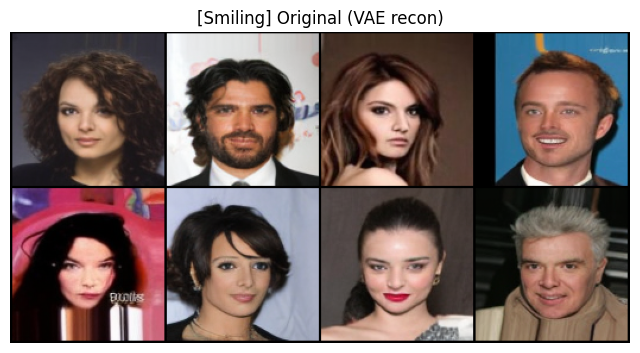

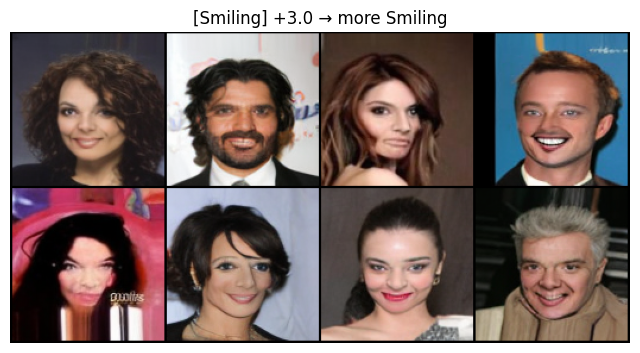

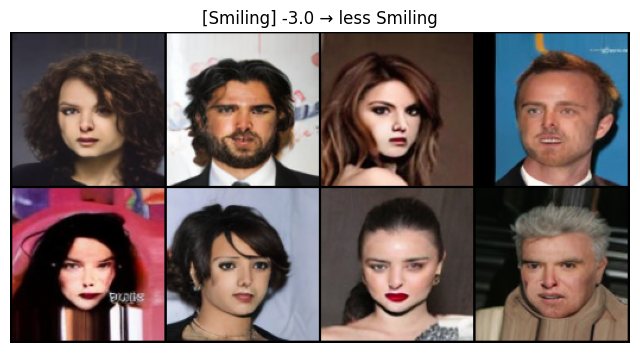

In [12]:
selected_attr = "Smiling"   # e.g. "Smiling", "Eyeglasses", "Young", "Male", "Heavy_Makeup"
probe_single, dir_single = train_probe_for_attribute_precomputed(selected_attr, cfg)
demo_edit_for_attribute_precomputed(selected_attr, dir_single, cfg, alpha=3.0)


Preparing latent loaders for attribute: Eyeglasses (idx 15)
Train latents: 2000, Val latents: 200
[Eyeglasses] flattened latent dim = 1024


[Eyeglasses] Epoch 1/10: 100%|██████████| 32/32 [00:00<00:00, 84.62it/s]


[Eyeglasses] Epoch 1: loss=0.2849 | val_acc=0.9050


[Eyeglasses] Epoch 2/10: 100%|██████████| 32/32 [00:00<00:00, 851.27it/s]


[Eyeglasses] Epoch 2: loss=0.2070 | val_acc=0.9100


...

[Eyeglasses] Epoch 8: loss=0.1045 | val_acc=0.9300


[Eyeglasses] Epoch 9/10: 100%|██████████| 32/32 [00:00<00:00, 877.29it/s]


[Eyeglasses] Epoch 9: loss=0.0948 | val_acc=0.9350


[Eyeglasses] Epoch 10/10: 100%|██████████| 32/32 [00:00<00:00, 333.02it/s]


[Eyeglasses] Epoch 10: loss=0.0881 | val_acc=0.9500


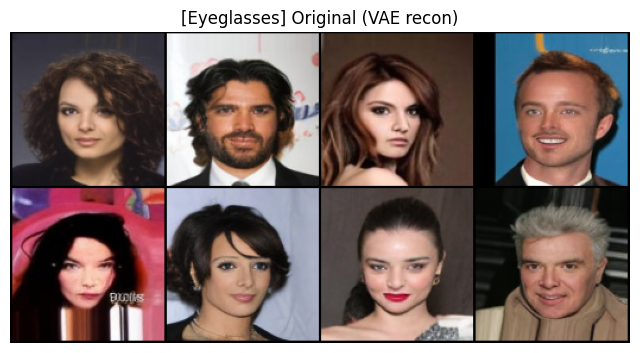

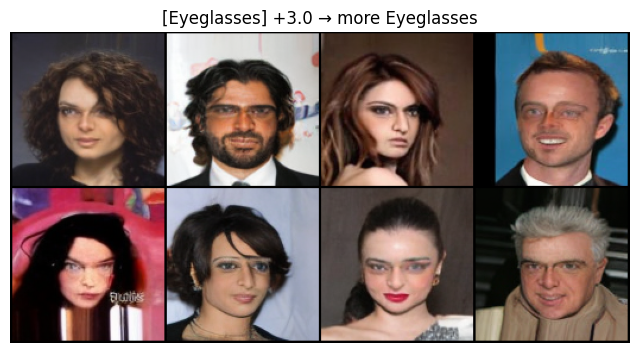

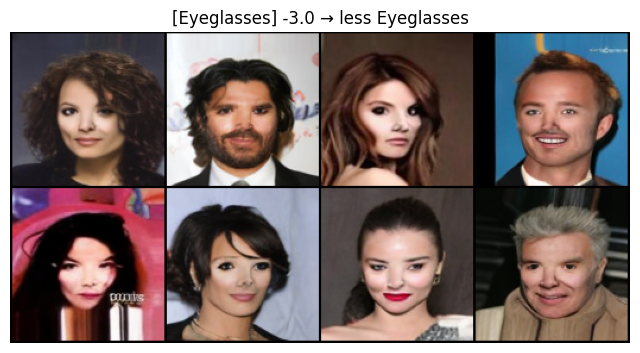

In [17]:
selected_attr = "Eyeglasses"   # e.g. "Smiling", , "Young", "Male", "Heavy_Makeup"
probe_single, dir_single = train_probe_for_attribute_precomputed(selected_attr, cfg)
demo_edit_for_attribute_precomputed(selected_attr, dir_single, cfg, alpha=3.0)


Preparing latent loaders for attribute: Young (idx 39)
Train latents: 2000, Val latents: 200
[Young] flattened latent dim = 1024


[Young] Epoch 1/10: 100%|██████████| 32/32 [00:00<00:00, 51.37it/s]


[Young] Epoch 1: loss=0.5390 | val_acc=0.7350


[Young] Epoch 2/10: 100%|██████████| 32/32 [00:00<00:00, 283.51it/s]


[Young] Epoch 2: loss=0.4608 | val_acc=0.7700


...

[Young] Epoch 8: loss=0.3586 | val_acc=0.7900


[Young] Epoch 9/10: 100%|██████████| 32/32 [00:00<00:00, 1455.94it/s]


[Young] Epoch 9: loss=0.3468 | val_acc=0.7900


[Young] Epoch 10/10: 100%|██████████| 32/32 [00:00<00:00, 1277.59it/s]


[Young] Epoch 10: loss=0.3388 | val_acc=0.7950


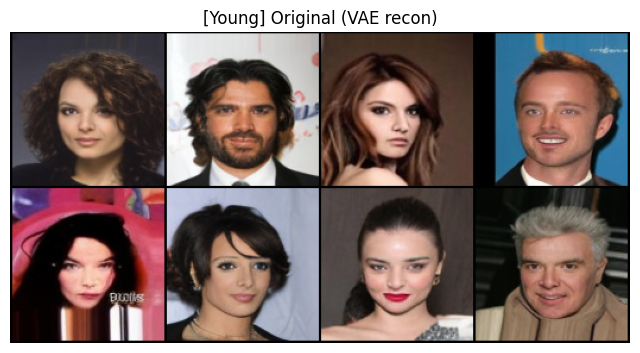

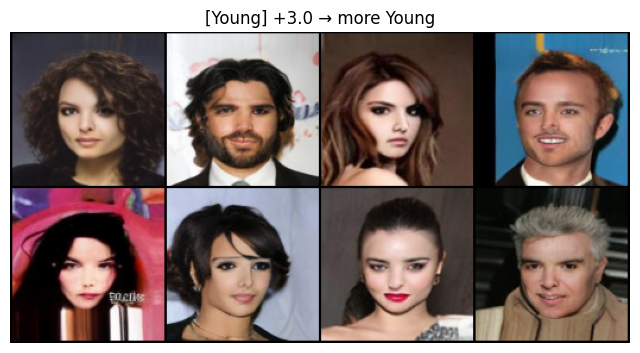

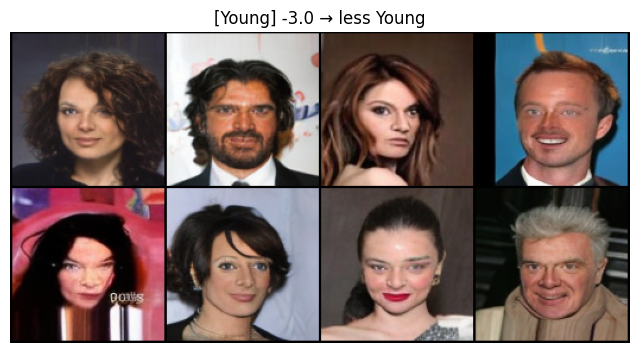

In [21]:
selected_attr = "Young"   # e.g. "Smiling", , "Young", "Male", "Heavy_Makeup"
probe_single, dir_single = train_probe_for_attribute_precomputed(selected_attr, cfg)
demo_edit_for_attribute_precomputed(selected_attr, dir_single, cfg, alpha=3.0)


Preparing latent loaders for attribute: Receding_Hairline (idx 28)
Train latents: 2000, Val latents: 200
[Receding_Hairline] flattened latent dim = 1024


[Receding_Hairline] Epoch 1/10: 100%|██████████| 32/32 [00:00<00:00, 256.00it/s]


[Receding_Hairline] Epoch 1: loss=0.3262 | val_acc=0.9200


[Receding_Hairline] Epoch 2/10: 100%|██████████| 32/32 [00:00<00:00, 963.10it/s]


[Receding_Hairline] Epoch 2: loss=0.2373 | val_acc=0.9200


...

[Receding_Hairline] Epoch 8: loss=0.1706 | val_acc=0.9200


[Receding_Hairline] Epoch 9/10: 100%|██████████| 32/32 [00:00<00:00, 1208.41it/s]


[Receding_Hairline] Epoch 9: loss=0.1618 | val_acc=0.9200


[Receding_Hairline] Epoch 10/10: 100%|██████████| 32/32 [00:00<00:00, 1432.10it/s]


[Receding_Hairline] Epoch 10: loss=0.1567 | val_acc=0.9200


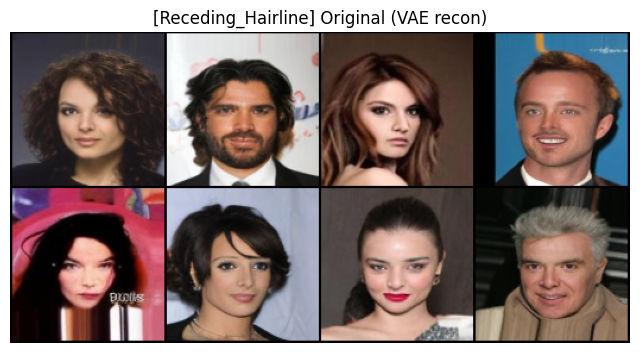

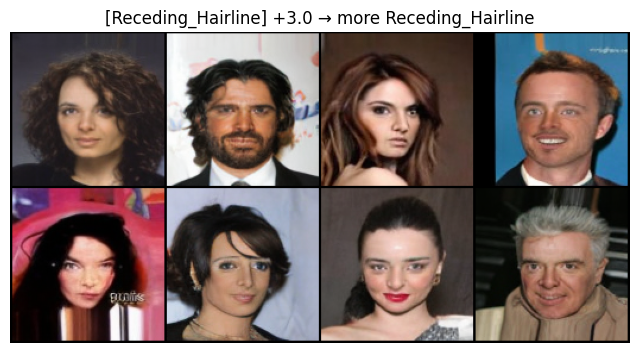

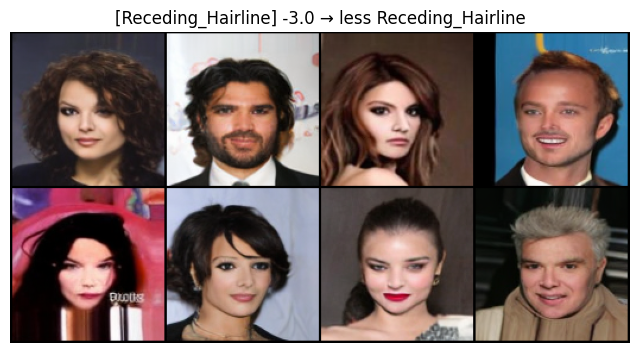

In [ ]:
selected_attr = "Receding_Hairline"   # e.g. "Smiling", "Young", "Male", "Heavy_Makeup"
probe_single, dir_single = train_probe_for_attribute_precomputed(selected_attr, cfg)
demo_edit_for_attribute_precomputed(selected_attr, dir_single, cfg, alpha=3.0)

## Multi-Attribute Combination


=== Training direction for Smiling ===

Preparing latent loaders for attribute: Smiling (idx 31)
Train latents: 2000, Val latents: 200
[Smiling] flattened latent dim = 1024


[Smiling] Epoch 1/10: 100%|██████████| 32/32 [00:00<00:00, 46.03it/s]


[Smiling] Epoch 1: loss=0.6323 | val_acc=0.7350


[Smiling] Epoch 2/10: 100%|██████████| 32/32 [00:00<00:00, 514.26it/s]


[Smiling] Epoch 2: loss=0.5103 | val_acc=0.7750


...

[Young] Epoch 8: loss=0.3528 | val_acc=0.8000


[Young] Epoch 9/10: 100%|██████████| 32/32 [00:00<00:00, 1253.42it/s]


[Young] Epoch 9: loss=0.3438 | val_acc=0.7850


[Young] Epoch 10/10: 100%|██████████| 32/32 [00:00<00:00, 1308.64it/s]


[Young] Epoch 10: loss=0.3396 | val_acc=0.7900


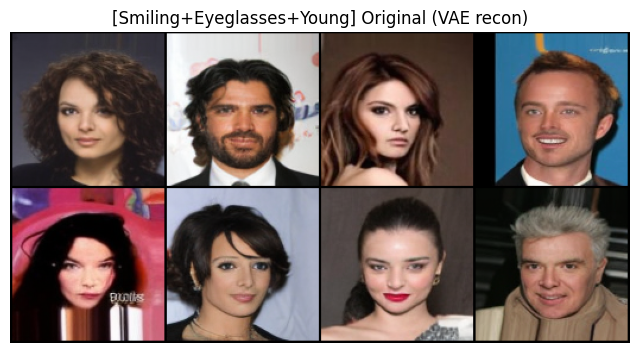

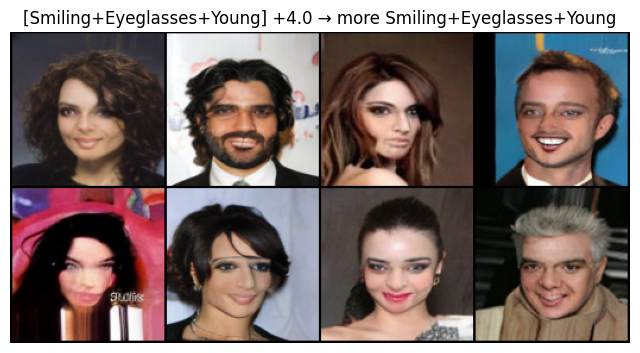

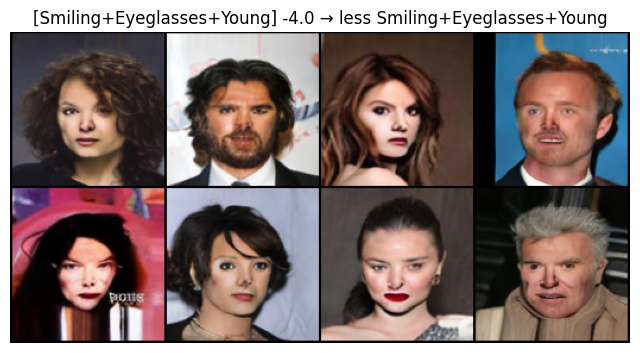

In [24]:
attrs_to_train = ["Smiling", "Eyeglasses", "Young"]  # choose any subset of CelebA attributes
directions: Dict[str, torch.Tensor] = {}

for attr in attrs_to_train:
    print(f"\n=== Training direction for {attr} ===")
    _, d_attr = train_probe_for_attribute_precomputed(attr, cfg)
    directions[attr] = d_attr

# combine directions: more smiling + somewhat younger + add glasses
combo_dir = (
    1.0 * directions["Smiling"] +
    0.7 * directions["Eyeglasses"] +
    0.8 * directions["Young"]
)
combo_dir = combo_dir / (combo_dir.norm() + 1e-8)

demo_edit_for_attribute_precomputed("Smiling+Eyeglasses+Young", combo_dir, cfg, alpha=cfg.edit_step_scale)

## Save Probes and Directions

In [20]:
os.makedirs("checkpoints", exist_ok=True)

# single-attribute
torch.save(probe_single.state_dict(), f"checkpoints/probe_{selected_attr}.pth")
torch.save(dir_single.cpu(),          f"checkpoints/direction_{selected_attr}.pt")
print("Saved single-attribute probe + direction.")

# multi-attribute directions
for attr, d in directions.items():
    torch.save(d.cpu(), f"checkpoints/direction_{attr}.pt")
    print(f"Saved direction for {attr}.")

Saved single-attribute probe + direction.
Saved direction for Smiling.
Saved direction for Big_Lips.
Saved direction for Rosy_Cheeks.
